In [1]:
import numpy as np
from miniproject.arena.banana import compute_log_concentration

We model the odor plume using an advection–diffusion–decay equation:

$$u\frac{\partial C}{\partial x} + v\frac{\partial C}{\partial y} = D\nabla^2 C - \lambda C + Q\,\delta(x-x_0)\,\delta(y-y_0)$$

where $\mathbf{x}=\begin{bmatrix}x\\y\end{bmatrix}$ is the position vector, $\mathbf{v}=\begin{bmatrix}u\\v\end{bmatrix}$ is the wind velocity, $D$ is the diffusivity, $\lambda$ is the decay rate, and $Q$ is the emission rate of the source located at $\mathbf{x}_0=\begin{bmatrix}x_0\\y_0\end{bmatrix}$.

The steady-state solution is:

$$C(x,y) = \frac{Q}{2\pi D}\exp\!\left(\frac{u(x-x_0)+v(y-y_0)}{2D}\right)K_0(\kappa\, r)$$

where $r = \|\mathbf{x}-\mathbf{x}_0\|$ is the distance from the source and $\kappa=\sqrt{\frac{\|\mathbf{v}\|^2}{4D^2} + \frac{\lambda}{D}}$ is a characteristic inverse length scale combining advection and decay. $K_0$ is the modified Bessel function of the second kind of order 0.

In the miniproject, for simplicity, we will assume the system attains a steady state immediately after the magnitude or direction of the wind changes, and we will use the above formula to compute the odor concentration at any point in the arena.

In [2]:
decay = 500.0
diffusivity = 20000
emission_rate = 1.0
n = 200
xy = np.ascontiguousarray(
    np.mgrid[-30 : 30 : n * 1j, -30 : 30 : n * 1j].reshape(2, -1).T[:, ::-1]
)
flow_velocity = np.array([0, 50000])
source_xy = np.array([0, 0])
log_concentration = compute_log_concentration(
    xy,
    source_xy,
    flow_velocity,
    diffusivity,
    decay,
    emission_rate,
)
concentration = np.exp(log_concentration).reshape(n, n)

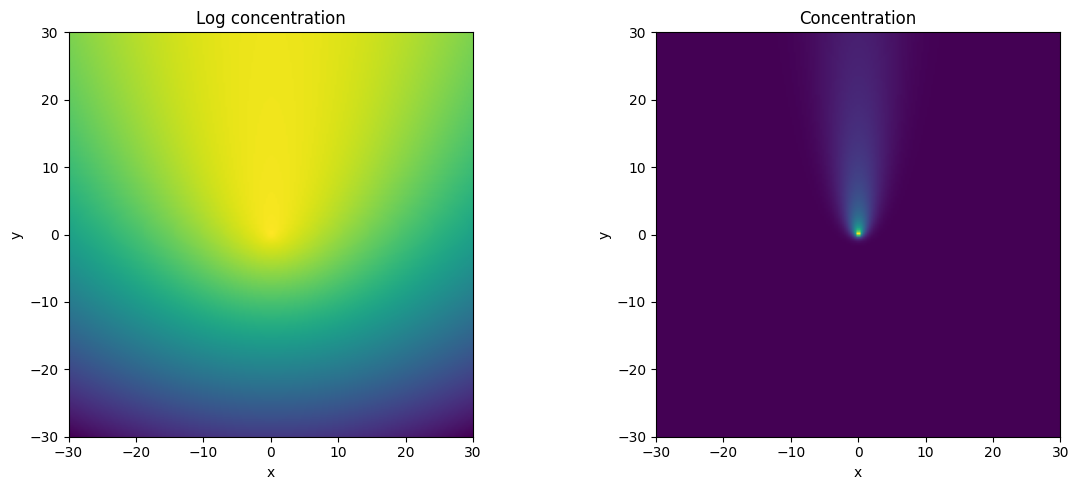

In [3]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
axs[0].imshow(
    log_concentration.reshape(n, n), extent=(-30, 30, -30, 30), origin="lower"
)
axs[0].set_title("Log concentration")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[1].imshow(concentration, extent=(-30, 30, -30, 30), origin="lower")
axs[1].set_title("Concentration")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
plt.tight_layout()